# Day 6 — COP vs Evaporator Temperature: Three Refrigerants Side by Side
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** a single COP number (like Day 5's) only tells you efficiency at one operating point. Real refrigerators run across a *range* of evaporator temperatures — a fresh-food compartment runs warmer than a freezer compartment, for instance. This notebook sweeps the evaporator temperature from -35°C to -5°C and tracks how COP changes for three refrigerants: **R134a** (older HFC, being phased out), **R600a** (isobutane, your IFB/LG charge), and **R290** (propane, the natural-refrigerant direction the industry is shifting toward).

**Condenser temperature held fixed at 40°C** for all three, so the comparison is fair.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Reusable cycle function (same as Day 5)
def calculate_cycle(T_evap_C, T_cond_C, refrigerant="R600a"):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15
    P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
    P_cond = CP.PropsSI("P","T",T_cond,"Q",1,refrigerant)
    h1 = CP.PropsSI("H","T",T_evap,"Q",1,refrigerant)
    s1 = CP.PropsSI("S","T",T_evap,"Q",1,refrigerant)
    h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)
    h3 = CP.PropsSI("H","T",T_cond,"Q",0,refrigerant)
    h4 = h3
    COP = (h1-h4)/(h2-h1)
    m_dot = 100/(h1-h4)
    return COP, m_dot, h1, h2, h3, h4, P_evap, P_cond

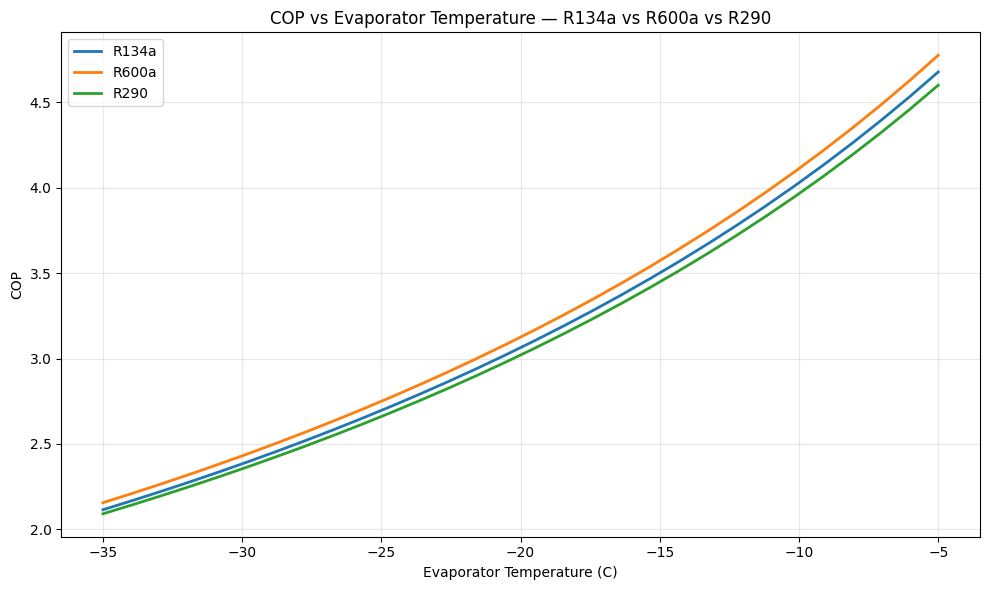

In [4]:
# CELL 4 — Sweep T_evap for each refrigerant and plot
T_cond = 40
refrigerants = ["R134a", "R600a", "R290"]
T_evap_range = np.linspace(-35, -5, 30)

plt.figure(figsize=(10,6))
for ref in refrigerants:
    COP_list = []
    for T_evap in T_evap_range:
        try:
            COP, *_ = calculate_cycle(T_evap, T_cond, ref)
            COP_list.append(COP)
        except:
            COP_list.append(None)
    plt.plot(T_evap_range, COP_list, label=ref, linewidth=2)

plt.xlabel("Evaporator Temperature (C)")
plt.ylabel("COP")
plt.title("COP vs Evaporator Temperature — R134a vs R600a vs R290")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("day06_refrigerant_comparison.png", dpi=150)
plt.show()

**What this graph tells us:** COP falls for *every* refrigerant as the evaporator gets colder — that's basic thermodynamics, not a refrigerant flaw: the compressor has to lift the refrigerant across a bigger pressure gap, which costs more work per kg of cooling delivered. This is exactly why a freezer compartment (very cold evaporator) is always less efficient to run than a fresh-food compartment (milder evaporator) on the same compressor.

The three lines stay close together across the whole range, with **R600a tracking marginally above R134a and R290 in this comparison** — useful evidence that the move away from R134a toward natural refrigerants like R600a/R290 (driven by GWP/F-Gas regulation, not just efficiency) doesn't come at an efficiency penalty.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day06_refrigerant_comparison.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 06 - COP vs evaporator temp, R134a vs R600a vs R290", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 06 - COP vs evaporator temp, R134a vs R600a vs R290", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
